In [6]:
import networkx as nx
import itertools
from math import comb
import matplotlib.pyplot as plt
from typing import List, Tuple, Set

In [7]:
def hamming_distance(a: int, b: int) -> int:
    """Distancia de Hamming entre dos enteros (popcount del XOR)."""
    return (a ^ b).bit_count()

def build_hamming_graph(n: int, d: int) -> nx.Graph:
    """
    Construye el grafo de Hamming H(n, d):
    - Vértices: números enteros de 0 a 2^n - 1 (representan palabras binarias)
    - Arista entre u y v si hamming_distance(u, v) >= d
    """
    num_vertices = 1 << n
    G = nx.Graph()
    G.add_nodes_from(range(num_vertices))
    for u in range(num_vertices):
        for v in range(u + 1, num_vertices):
            if hamming_distance(u, v) >= d:
                G.add_edge(u, v)
    return G


In [8]:
def bron_kerbosch_max_cliques(G: nx.Graph):
    """
    Implementación del algoritmo de Bron–Kerbosch (versión con pivote)
    que encuentra todos los cliques maximales en un grafo no dirigido.
    Adaptado del artículo original "Algorithm 457: Finding All Cliques of an Undirected Graph".
    Retorna una lista de cliques (cada clique es un conjunto de vértices).
    """
    # Convertir los vértices a enteros 0..N-1 (ya lo son)
    vertices = list(G.nodes())
    # Precalcular vecinos como lista de conjuntos para acceso rápido
    neighbors = {v: set(G.neighbors(v)) for v in vertices}
    N = len(vertices)
    # Orden inicial: todos los vértices en "candidates", "not" vacío
    all_vertices = vertices[:]  # lista de todos los vértices en orden
    compsub = []  # R, clique en construcción
    cliques = []  # almacenará los cliques maximales encontrados

    def extend(old, ne, ce):
        """
        old: lista de vértices (primero 'not' (0..ne-1), luego 'candidates' (ne..ce-1))
        ne: número de vértices en not (0 <= ne <= ce)
        ce: número total de elementos en old (len(old))
        """
        nonlocal cliques
        # Paso 1: elegir punto fijo (fixp) con mínimo número de disconexiones
        minnod = ce
        fixp = None
        s = -1
        nod = 0  # indicador si el punto fijo se tomó de candidates (1) o not (0)
        i = 0
        while i < ce and minnod != 0:
            p = old[i]
            count = 0
            # Contar disconexiones con el resto de candidatos (desde ne hasta ce-1)
            j = ne
            pos = -1
            while j < ce and count <= minnod:
                if p not in neighbors[old[j]]:  # disconexión
                    count += 1
                    pos = j
                j += 1
            if count < minnod:
                fixp = p
                minnod = count
                if i < ne:
                    s = pos
                else:
                    s = i
                    nod = 1
            i += 1

        # Bucle principal de backtracking
        # nod iterará desde minnod + nod hasta 1
        for _ in range(minnod + nod, 0, -1):
            # Intercambiar el candidato seleccionado (old[s]) con old[ne]
            p = old[s]
            old[s] = old[ne]
            sel = old[ne]
            old[ne] = p

            # Construir nuevo conjunto 'not' (new) y 'candidates' (newcand)
            new = [0] * ce  # preasignamos tamaño máximo
            newne = 0
            # Copiar vértices de 'not' que son vecinos de sel
            for i in range(ne):
                if sel in neighbors[old[i]]:
                    new[newne] = old[i]
                    newne += 1
            newce = newne
            # Copiar vértices de 'candidates' (desde ne+1 hasta ce-1) que son vecinos de sel
            # Nota: el índice ne ya contiene sel, que fue movido; lo saltamos
            for i in range(ne + 1, ce):
                if sel in neighbors[old[i]]:
                    new[newce] = old[i]
                    newce += 1

            compsub.append(sel)

            if newce == 0:
                # Se encontró un clique maximal
                cliques.append(compsub.copy())
            else:
                if newne < newce:
                    # Llamada recursiva con el nuevo conjunto
                    # new[:newce] contiene (not + candidates)
                    extend(new, newne, newce)

            compsub.pop()
            # Mover sel al conjunto 'not' para futuras iteraciones
            ne += 1

            # Si aún quedan candidatos por procesar (nod > 1), seleccionar el siguiente
            # candidato desconectado del punto fijo
            if nod > 1:
                # Buscar siguiente candidato (pos > s) que esté desconectado de fixp
                s = ne
                while s < ce and fixp in neighbors[old[s]]:
                    s += 1
                if s >= ce:
                    break
                # El siguiente candidato ya está en old[s], listo para el siguiente ciclo
            else:
                # Solo un candidato, terminar
                break

    # Iniciar llamada con todos los vértices en candidates, not vacío
    extend(all_vertices, 0, N)
    return cliques


In [17]:
G= build_hamming_graph(6,4)
cliques = bron_kerbosch_max_cliques(G)
cliques

[[0, 15, 51, 60]]

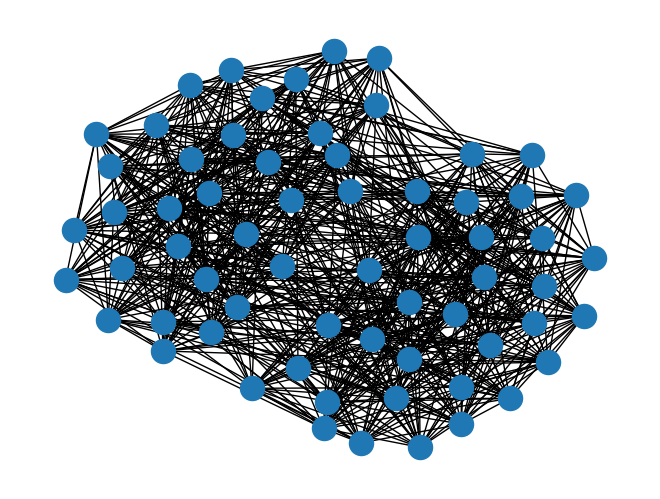

In [18]:
nx.draw(G)

In [ ]:
import sys
import time
'Funcion que calcula de manera muy rapida pero de manera incorrecta'
sys.setrecursionlimit(1000000)

def hamming_distance(x: int, y: int, n: int) -> int:
    return (x ^ y).bit_count()

def build_conflict_graph(n: int, d: int):
    N = 1 << n
    adj = [0] * N
    for i in range(N):
        for j in range(i + 1, N):
            if hamming_distance(i, j, n) < d:
                adj[i] |= (1 << j)
                adj[j] |= (1 << i)
    return adj, N

def max_independent_set(adj, N, use_translation=True, verbose=False):
    max_size = 0
    # Grados para posible orden inicial (no utilizado directamente)
    # degrees = [adj[i].bit_count() for i in range(N)]

    # Coloración greedy (Tomita) con corrección del número de colores
    def greedy_color(cand_bits):
        # Extraer lista de vértices
        vertices = []
        bits = cand_bits
        while bits:
            v = (bits & -bits).bit_length() - 1
            vertices.append(v)
            bits &= bits - 1
        if not vertices:
            return [], 0
        # Ordenar por grado descendente dentro del subgrafo
        vertices.sort(key=lambda v: (cand_bits & adj[v]).bit_count(), reverse=True)
        color = {}
        max_color = -1
        for v in vertices:
            used = set()
            neigh = adj[v] & cand_bits
            nbits = neigh
            while nbits:
                u = (nbits & -nbits).bit_length() - 1
                if u in color:
                    used.add(color[u])
                nbits &= nbits - 1
            c = 0
            while c in used:
                c += 1
            color[v] = c
            if c > max_color:
                max_color = c
        num_colors = max_color + 1   # <--- CORRECCIÓN AQUÍ
        # Ordenar por color descendente
        sorted_vertices = sorted(vertices, key=lambda v: color[v], reverse=True)
        return sorted_vertices, num_colors

    # Búsqueda recursiva
    def expand(current_bits, cand_bits):
        nonlocal max_size
        cur_sz = current_bits.bit_count()
        # Poda por tamaño simple
        if cur_sz + cand_bits.bit_count() <= max_size:
            return
        if cand_bits == 0:
            if cur_sz > max_size:
                max_size = cur_sz
                if verbose:
                    print(f"Nueva clique de tamaño {max_size}")
            return

        # Obtener orden y cota por coloración
        sorted_cand, colors = greedy_color(cand_bits)
        if cur_sz + colors <= max_size:
            return

        # Iterar sobre candidatos
        for v in sorted_cand:
            v_bit = 1 << v
            if not (cand_bits & v_bit):
                continue
            # Nuevos candidatos: eliminar v y todos sus vecinos
            new_cand = cand_bits & ~(adj[v] | v_bit)
            expand(current_bits | v_bit, new_cand)
            # Eliminar v de cand_bits para futuras iteraciones
            cand_bits &= ~v_bit
            # Poda adicional
            if cur_sz + cand_bits.bit_count() <= max_size:
                break

    # Inicialización: fijar el vértice 0 si se usa traslación
    if use_translation:
        all_vertices = (1 << N) - 1
        # El vértice 0 está en la solución, luego sus vecinos y él mismo quedan fuera de candidatos
        current = 1 << 0
        cand = all_vertices & ~(adj[0] | (1 << 0))
        expand(current, cand)
    else:
        expand(0, (1 << N) - 1)

    return max_size

def A(n, d):
    print(f"Construyendo grafo de conflictos para n={n}, d={d}...")
    adj, N = build_conflict_graph(n, d)
    print(f"Vértices totales: {N}")

    # Para distancia par, restringir a peso par (reduce a la mitad)
    if d % 2 == 0 and n >= d:
        even_vertices = [i for i in range(N) if i.bit_count() % 2 == 0]
        M = len(even_vertices)
        print(f"Reduciendo a {M} vértices (solo peso par)")
        old_to_new = {v: idx for idx, v in enumerate(even_vertices)}
        new_adj = [0] * M
        for i, v in enumerate(even_vertices):
            mask = 0
            neigh = adj[v]
            for u in even_vertices:
                if (neigh >> u) & 1:
                    mask |= (1 << old_to_new[u])
            new_adj[i] = mask
        # Nota: en el grafo reducido, la traslación se aplica sobre índices nuevos
        # Sin embargo, el vértice que originalmente era 0 (si es par) se convierte en el índice correspondiente
        # Para mantener la simetría, seguimos usando traslación (fijamos el nuevo índice del 0)
        # En este caso, el 0 original (que tiene peso 0) siempre está en even_vertices, y su nuevo índice es old_to_new[0].
        # El algoritmo de MIS con traslación ya fija el vértice 0 (el nuevo índice 0). Pero cuidado: el nuevo índice 0 puede no corresponder al vértice 0 original.
        # La traslación es válida sobre el grafo reducido porque el código óptimo se puede trasladar dentro del subespacio de peso par? Esto requiere verificación.
        # Por simplicidad, llamamos a max_independent_set con use_translation=True; el vértice fijo será el de índice 0 en el nuevo grafo.
        # Para que sea correcto, debemos reindexar de modo que el nuevo vértice 0 sea el que tenía peso 0 original.
        # En even_vertices, el 0 original está en la posición 0 si hemos construido la lista en orden ascendente (por construcción, even_vertices está ordenada).
        # Por lo tanto, el nuevo índice 0 corresponde al vértice 0 original. Así que use_translation=True es correcto.
        result = max_independent_set(new_adj, M, use_translation=True)
        return result
    else:
        return max_independent_set(adj, N, use_translation=True)

if __name__ == "__main__":
    tests = [(9,4)]  # Primero probamos este; luego (9,4) y (10,4)
    for n, d in tests:
        start = time.time()
        res = A(n, d)
        elapsed = time.time() - start
        print(f"A({n},{d}) = {res}  (tiempo: {elapsed:.2f} segundos)")

Construyendo grafo de conflictos para n=9, d=4...
Vértices totales: 512
Reduciendo a 256 vértices (solo peso par)
A(9,4) = 18  (tiempo: 12.34 segundos)


In [ ]:
import sys
import time
'funcion que calcula correctamente el clan maximal de la grafica de hamming'
'sin embargo no es eficiente calculando grafos densos como A(8,3) en adelante'
sys.setrecursionlimit(1000000)

def hamming_distance(x: int, y: int, n: int) -> int:
    return (x ^ y).bit_count()

def build_adjacency_bitsets(n: int, d: int, even_only: bool = False):
    """Grafo de adyacencia: arista si distancia >= d.
    Si even_only=True, solo vértices de peso par."""
    total = 1 << n
    vertices = [v for v in range(total) if (not even_only) or (v.bit_count() % 2 == 0)]
    N = len(vertices)
    idx = {v: i for i, v in enumerate(vertices)}
    adj = [0] * N
    for a in range(N):
        for b in range(a + 1, N):
            if hamming_distance(vertices[a], vertices[b], n) >= d:
                adj[a] |= (1 << b)
                adj[b] |= (1 << a)
    return adj, N, vertices

def greedy_color(P_bits, adj):
    """Coloreo greedy del subgrafo inducido por P_bits.
    Devuelve (lista_vertices_ordenados, número_de_colores)."""
    # Extraer lista de vértices
    verts = []
    bits = P_bits
    while bits:
        v = (bits & -bits).bit_length() - 1
        verts.append(v)
        bits &= bits - 1
    if not verts:
        return [], 0
    # Ordenar por grado descendente dentro del subgrafo
    verts.sort(key=lambda v: (P_bits & adj[v]).bit_count(), reverse=True)
    color = {}
    max_c = -1
    for v in verts:
        used = set()
        neigh = adj[v] & P_bits
        nbits = neigh
        while nbits:
            u = (nbits & -nbits).bit_length() - 1
            if u in color:
                used.add(color[u])
            nbits &= nbits - 1
        c = 0
        while c in used:
            c += 1
        color[v] = c
        if c > max_c:
            max_c = c
    num_colors = max_c + 1
    # Ordenar por color descendente
    sorted_verts = sorted(verts, key=lambda v: color[v], reverse=True)
    return sorted_verts, num_colors

def greedy_initial_clique(adj, N):
    """Cota inferior rápida: clique greedy."""
    order = list(range(N))
    order.sort(key=lambda v: -adj[v].bit_count())
    current = 0
    for v in order:
        if (current & adj[v]) == current:
            current |= (1 << v)
    return current.bit_count()

def max_clique_tomita(adj, N, use_translation=True):
    """Algoritmo de Tomita para el tamaño de la clique máxima."""
    max_size = greedy_initial_clique(adj, N)

    if use_translation:
        # Fijamos el vértice 0 (índice 0) en la clique
        R0 = 1 << 0
        P0 = (1 << N) - 1
        P0 &= adj[0]          # solo vecinos de 0
        X0 = 0
    else:
        R0 = 0
        P0 = (1 << N) - 1
        X0 = 0

    def expand(R_bits, P_bits, X_bits):
        nonlocal max_size
        cur_sz = R_bits.bit_count()
        # Poda simple
        if cur_sz + P_bits.bit_count() <= max_size:
            return
        if P_bits == 0 and X_bits == 0:
            if cur_sz > max_size:
                max_size = cur_sz
            return
        # Poda por coloración
        sorted_cand, colors = greedy_color(P_bits, adj)
        if cur_sz + colors <= max_size:
            return
        # Pivote: vértice en P∪X con mayor vecindario en P
        union = P_bits | X_bits
        best_u = -1
        best_deg = -1
        temp = union
        while temp:
            u_bit = temp & -temp
            u = u_bit.bit_length() - 1
            deg = (P_bits & adj[u]).bit_count()
            if deg > best_deg:
                best_deg = deg
                best_u = u
            temp ^= u_bit
        # Candidatos = P \ N(best_u)
        candidates = P_bits & ~adj[best_u]
        for v in sorted_cand:
            v_bit = 1 << v
            if not (candidates & v_bit):
                continue
            expand(R_bits | v_bit,
                   P_bits & adj[v],
                   X_bits & adj[v])
            P_bits &= ~v_bit
            X_bits |= v_bit
            if cur_sz + P_bits.bit_count() <= max_size:
                break

    expand(R0, P0, X0)
    return max_size

def A(n, d):
    """Calcula A(n,d) mediante búsqueda de clique máxima."""
    even_only = (d % 2 == 0)   # reducción por paridad
    print(f"Construyendo grafo de adyacencia (distancia ≥ {d}) para n={n}...")
    adj, N, vertices = build_adjacency_bitsets(n, d, even_only)
    print(f"Vértices: {N} (reducción por paridad: {even_only})")
    start = time.time()
    res = max_clique_tomita(adj, N, use_translation=True)
    elapsed = time.time() - start
    print(f"A({n},{d}) = {res}  (tiempo: {elapsed:.2f} segundos)")
    return res

if __name__ == "__main__":
    A(8, 4)   # debe dar 20
    # A(8, 3)   # 16
    # A(9, 4)   # 20
    # A(10, 4)  # 40

Construyendo grafo de adyacencia (distancia ≥ 4) para n=8...
Vértices: 128 (reducción por paridad: True)
A(8,4) = 16  (tiempo: 1.82 segundos)
